# Log-Gamma Distribution

`LogGamma(shape)` is the distribution of the **logarithm of** a gamma random variable: take a `Gamma`, take its log, and this is what you get. Taking the log squashes the gamma's long right tail and stretches out its left side, so the result is a left-skewed distribution spread over *all* the real numbers -- negative values are completely ordinary. It shows up in extreme value theory, and in actuarial work as a model on the log scale of a loss.

**Read the name carefully -- it points the opposite way from `LogNormal`.** A log-normal variable is one *whose own logarithm* is normal, so it is always positive. A log-gamma variable, by the convention used here, *is itself a logarithm*, so it happily goes negative. In short:

- `log(LogNormal)` is Normal
- `exp(LogGamma)` is Gamma

We come back to this at the end and show it on a plot.

In [1]:
from symbulate import *

## Draw a value from a log-gamma distribution

In [2]:
LogGamma(shape=2).draw()

-0.4995262650732885

## Theoretical mean, variance, and standard deviation

These have tidy closed forms: the mean is the digamma function of the shape, and the variance is the trigamma function of it. Notice the mean can be negative -- for `shape` below about 1.46 it is.

In [3]:
LogGamma(shape=2).mean(), LogGamma(shape=2).var(), LogGamma(shape=2).sd()

(np.float64(0.42278433509846713),
 np.float64(0.6449340668482266),
 np.float64(0.8030778709740586))

In [4]:
[float(LogGamma(shape=s).mean()) for s in [0.5, 1, 2, 5]]

[-1.9635100260214235,
 -0.5772156649015329,
 0.42278433509846713,
 1.5061176684318003]

## Assign and simulate a random variable

In [5]:
L = RV(LogGamma(shape=2))
L.sim(10000)

0,0.3205484599411208
1,0.9262423554084721
2,0.9599983503515838
3,1.258259375536101
4,0.3165468426872228
5,1.4038537872688535
6,-0.9629671381108899
7,-0.12514461893069084
8,0.5873548276952982
...,...
9999,1.1716595681535613


## Plot the pdf

A single peak with a long tail running off to the *left* -- the opposite lean from the gamma it came from. Note that the curve extends well below zero.

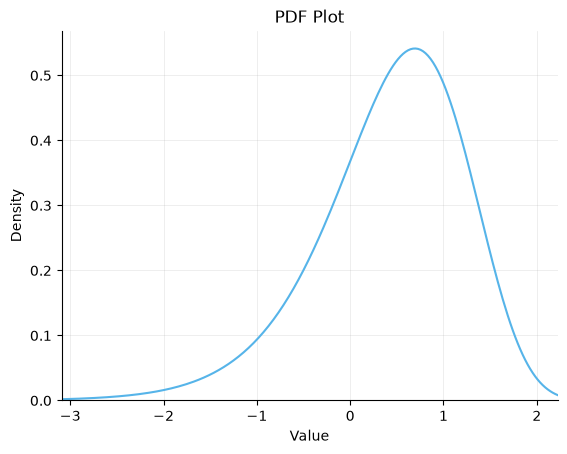

In [6]:
LogGamma(shape=2).plot()

## Plot the CDF

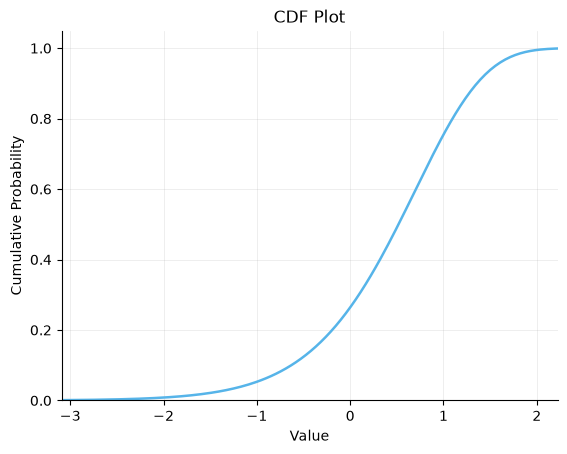

In [7]:
LogGamma(shape=2).plot(cdf=True)

## Simulated values against the theoretical curve

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


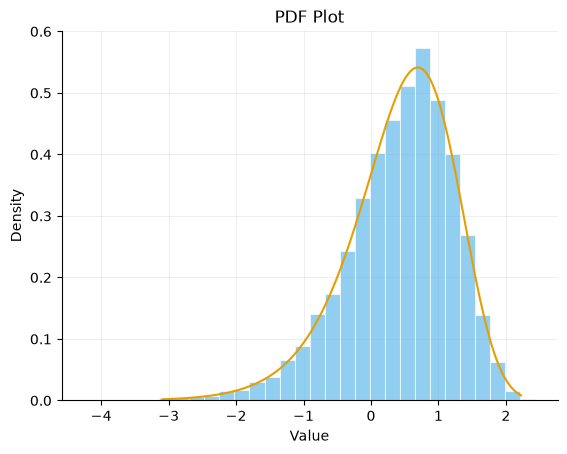

In [8]:
L.sim(10000).plot()
LogGamma(shape=2).plot()

## The shape parameter controls the skew

A small shape gives a heavily left-skewed curve with a long tail; as the shape grows the distribution tightens up, shifts to the right, and becomes nearly symmetric.

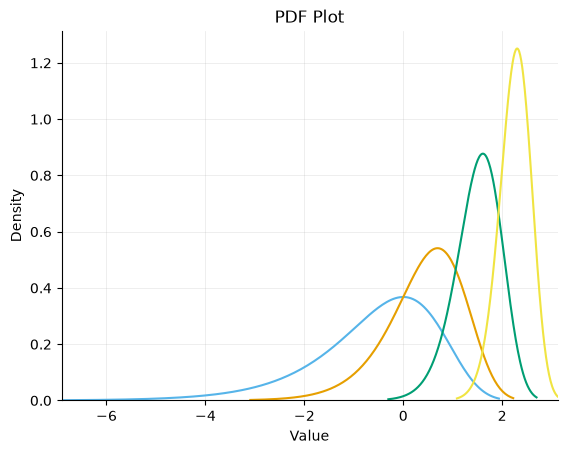

In [9]:
for s in [1, 2, 5, 10]:
    LogGamma(shape=s).plot()

## Relationship: it is the log of a gamma

This is the definition. Simulate a `Gamma`, apply `log` to it, and the results follow the `LogGamma` curve.

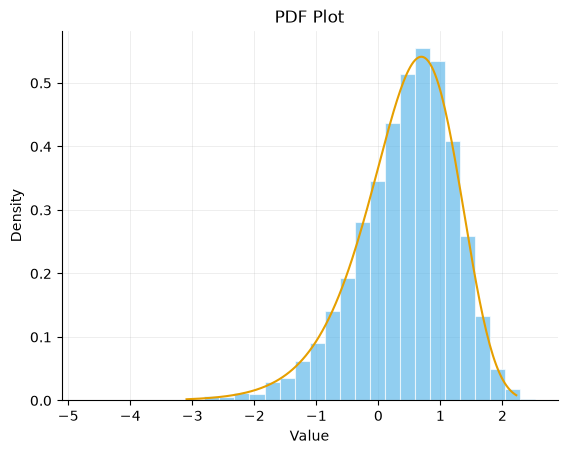

In [10]:
G = RV(Gamma(shape=2, scale=1))
G.apply(log).sim(10000).plot()
LogGamma(shape=2).plot()

## The same fact read backwards: exponentiating gives a gamma

Going the other direction is the clearest way to pin down which distribution this is. Take a `LogGamma`, apply `exp`, and you land back on a `Gamma` -- including all those negative values, which map to gamma values between 0 and 1.

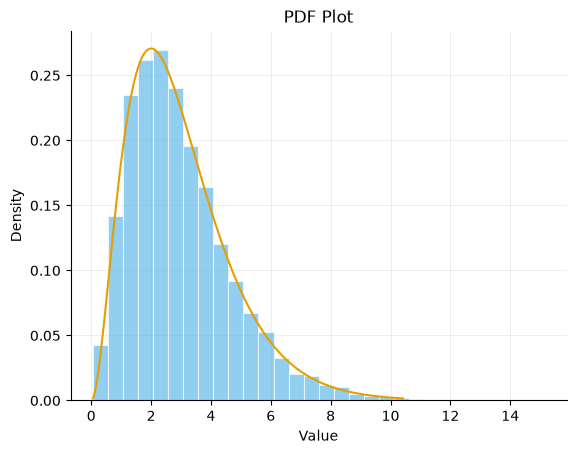

In [11]:
X = RV(LogGamma(shape=3))
X.apply(exp).sim(10000).plot()
Gamma(shape=3).plot()

## Comparison: log-gamma and log-normal point opposite ways

Here is the naming trap from the top of the notebook, on a plot. The `LogNormal` stops dead at 0 -- it is `exp` of something, so it cannot be negative. The `LogGamma` slides straight through zero into the negatives, because it *is* a log.

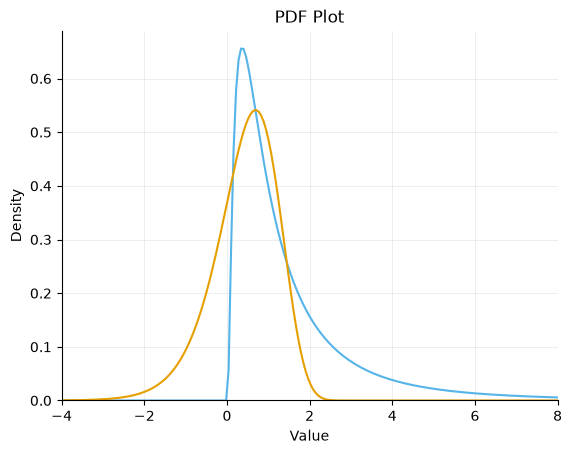

In [12]:
LogNormal(mu=0, sigma=1).plot(xlim=(-4, 8))
LogGamma(shape=2).plot(xlim=(-4, 8))

The 1st percentile of each makes the same point in numbers: one is comfortably positive, the other is well below zero.

In [13]:
float(LogNormal(mu=0, sigma=1).quantile(0.01)), float(LogGamma(shape=2).quantile(0.01))

(0.09765173307033599, -1.906801767429384)

## Relationship: `shape = 1` is a mirrored Gumbel

With `shape = 1` the log-gamma becomes the smallest-extreme-value distribution. That is the **mirror image** of this package's `Gumbel`, which models *largest* values -- not the same distribution. Reflecting one about 0 gives the other, so their tails run in opposite directions from a shared peak.

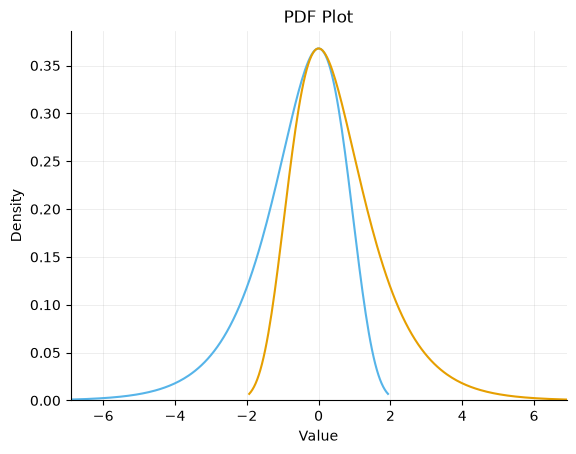

In [14]:
LogGamma(shape=1).plot()
Gumbel(loc=0, scale=1).plot()

In [15]:
# Mirrored: the density at x on one matches the density at -x on the other.
[(float(LogGamma(shape=1).pdf(x)), float(Gumbel(loc=0, scale=1).pdf(-x))) for x in [-1.5, 0.0, 1.5]]

[(0.17850651851312094, 0.17850651851312094),
 (0.36787944117144233, 0.36787944117144233),
 (0.05070711360998073, 0.05070711360998073)]

## Shifting and stretching with `loc` and `scale`

`loc` slides the distribution along and `scale` stretches it, giving `mean = loc + scale * digamma(shape)`. Careful: `scale` stretches the log-gamma variable itself -- it is *not* the scale of the underlying gamma distribution.

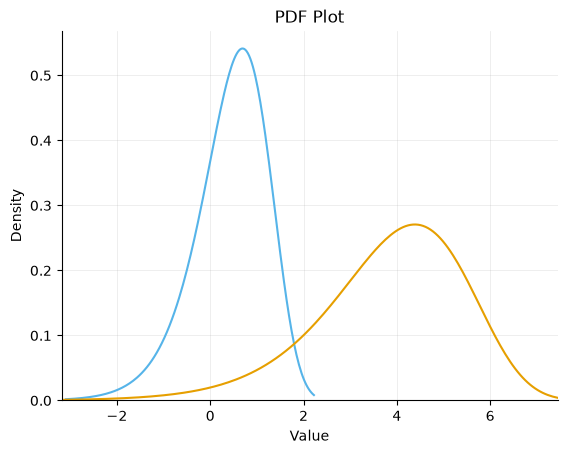

In [16]:
LogGamma(shape=2).plot()
LogGamma(shape=2, loc=3, scale=2).plot()